In [2]:
from src import utils
import numpy as np
from scipy.spatial import distance
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
maps = [
    {'name':'Eucl.', 
     'path':'../data/schaefer200_centroids.csv'},
    {'name':'Sph. Eucl.', 
     'path':'../data/schaefer200_LH_sphere_coords.txt'},
    {'name':'U-T', 
     'path':'../data/schaefer200_ut-axis.npy'},
    {'name':'S-A', 
     'path':'../data/schaefer200_sa-axis.npy'},
    {'name':'S-F',
     'path':'../data/schaefer200_cyto.npy'},
    {'name': '../data/schaefer200_myelin.npy'}
]

n_maps = len(maps)

# euclidean
centroids = pd.read_csv(maps[0]['path'])[:100]
roi_names = centroids['ROI Name'].str.replace('7Networks_LH_','')
centroids.set_index("ROI Name", inplace=True)
brain_map = centroids.to_numpy()
maps[0]['map_norm'] = utils.normalize_x(utils.get_brainmap_distance(brain_map))
maps[0]['map'] = utils.get_brainmap_distance(brain_map)

# s-a axis
brain_map = np.load(maps[1]['path'])[:100]
maps[1]['map_norm'] = utils.normalize_x(utils.get_brainmap_distance(brain_map))
maps[1]['map'] = utils.get_brainmap_distance(brain_map)

# u-t axis
brain_map = np.load(maps[2]['path'])[:100]
maps[2]['map_norm'] = utils.normalize_x(utils.get_brainmap_distance(brain_map))
maps[2]['map'] = utils.get_brainmap_distance(brain_map)

# plot
h = 5
w = h * 1.1 * n_maps
fig, ax = plt.subplots(1, n_maps, figsize=(w,h), squeeze=True, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)
for idx in np.arange(n_maps):
    sns.heatmap(maps[idx]['map'], ax=fig.axes[idx], cbar=1)
    fig.axes[idx].set_aspect('equal')
    fig.axes[idx].set_title(maps[idx]['name'])
yticks = np.arange(0,100,5)
fig.axes[0].set_yticks(yticks)
fig.axes[0].set_yticklabels(roi_names[yticks])


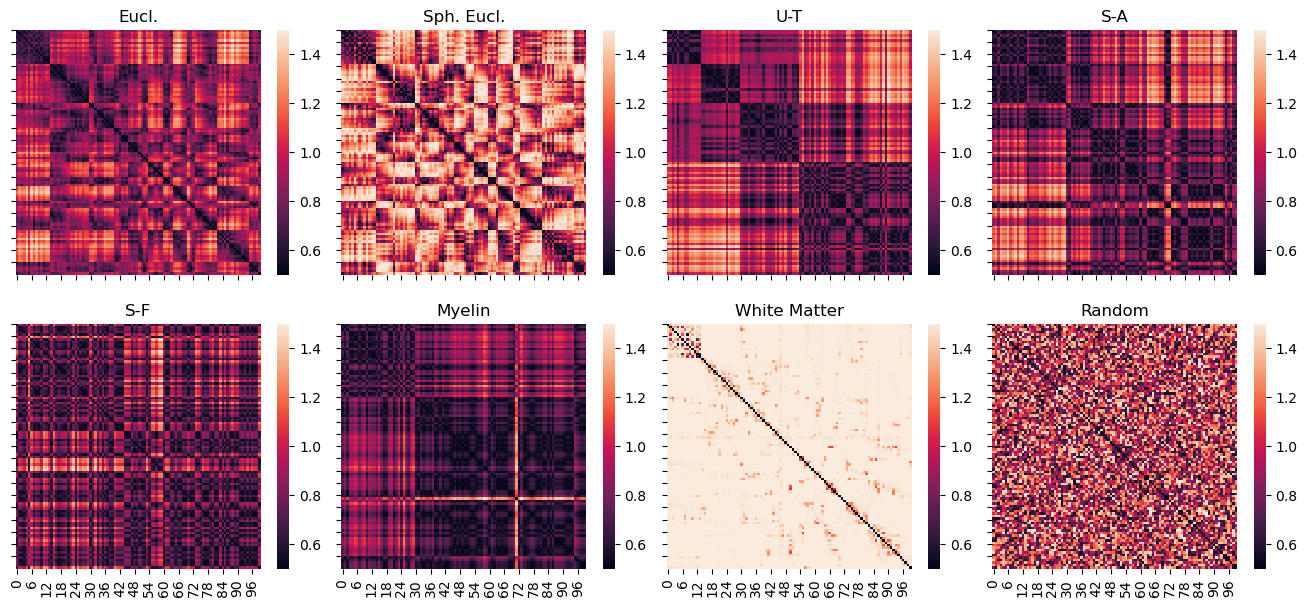

In [ ]:
datadir = '../data'
maps = [
    {'name': 'Eucl.', 
     'code': 'euclidean'},
    {'name': 'Sph. Eucl.', 
     'code': 'sphere_euclidean'},
    {'name': 'U-T', 
     'code': 'ut_axis'},
    {'name': 'S-A', 
     'code': 'sa_axis'},
    {'name': 'S-F',
     'code': 'sf_axis'},
    {'name': 'Myelin',
     'code': 'myelin'},
    {'name': 'White Matter',
     'code': 'struct_conn'},
    {'name': 'Random',
     'code': 'rand_uniform'}
]

n_maps = len(maps)


In [ ]:
h = 7
w = h * 0.3 * n_maps
fig, ax = plt.subplots(2, int(n_maps*0.5), figsize=(w,h), 
                       squeeze=True, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)

for idx in np.arange(n_maps):
    this = maps[idx]
    this_map_norm, this_map = utils.load_embedding(kernel_type=this['code'],
                                                   datadir=datadir)
    this['map'] = this_map
    this['map_norm'] = utils.normalize_x(this_map,'mean')
    
    sns.heatmap(this_map_norm, ax=fig.axes[idx], cbar=1, vmin=0.5, vmax=1.5)
    fig.axes[idx].set_aspect('equal')
    fig.axes[idx].set_title(maps[idx]['name'])

yticks = np.arange(0,100,5)
fig.axes[0].set_yticks(yticks)
plt.show()
# fig.axes[0].set_yticklabels(roi_names[yticks])


In [ ]:
methods = [
    'rescale',
    'mean',
    'mean_std',
    # 'meansq',
    'uniform'
]
n_methods = len(methods)

h = 7
w = h * 0.3 * n_maps
fig, ax = plt.subplots(2, int(n_maps*0.5), figsize=(w,h), 
                       squeeze=True, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)

for idx in np.arange(n_maps):
    this = maps[idx]
    this_map_norm, this_map = utils.load_embedding(kernel_type=this['code'],
                                                   datadir=datadir)
    this['map'] = this_map
    this['map_norm'] = utils.normalize_x(this_map,'mean')
    
    sns.heatmap(this_map_norm, ax=fig.axes[idx], cbar=1, vmin=0.5, vmax=1.5)
    fig.axes[idx].set_aspect('equal')
    fig.axes[idx].set_title(maps[idx]['name'])

yticks = np.arange(0,100,5)
fig.axes[0].set_yticks(yticks)
plt.show()

In [33]:
import pickle
xfile = '/Volumes/Sabrent_2TB/rutgers/HCP/collated/hcpya_connectome.pkl'
with open(xfile, 'rb') as f:
    xdata = pickle.load(f)
f.close()

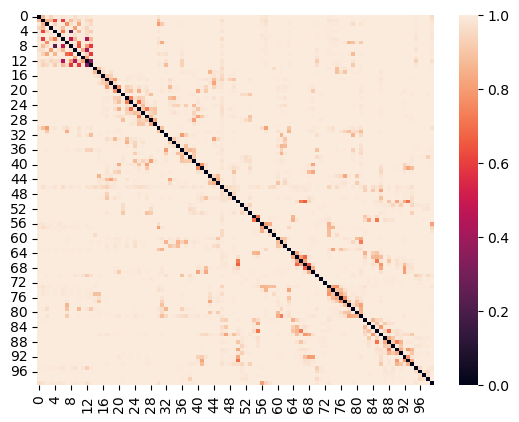

In [112]:
subs = xdata.keys()
n = len(subs)
xc = np.zeros((200,200))
xb = np.zeros((200,200))
for s in subs:
    this = xdata[s]['Schaefer2007'] 
    xb = xb + np.float32(this>0)
mask = (xb / n) > 0.99
for s in subs:
    this = xdata[s]['Schaefer2007'] 
    xc = xc + this * mask
xc = xc / n
xd = 1-xc
xd[np.eye(200)>0] = 0
xdn = utils.normalize_x(xd) - 0.5 
xdn[np.eye(200)>0] = 0
sns.heatmap(xdn[:100,:100], vmin=0, vmax=1) 
np.save('../data/schaefer200_structural_conn_kernel.npy', xdn)

['RNN', 'Eucl.', 'Sph. Eucl.', 'U-T', 'S-A', 'S-F', 'Myelin', 'White Matter', 'Random']
[0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002]


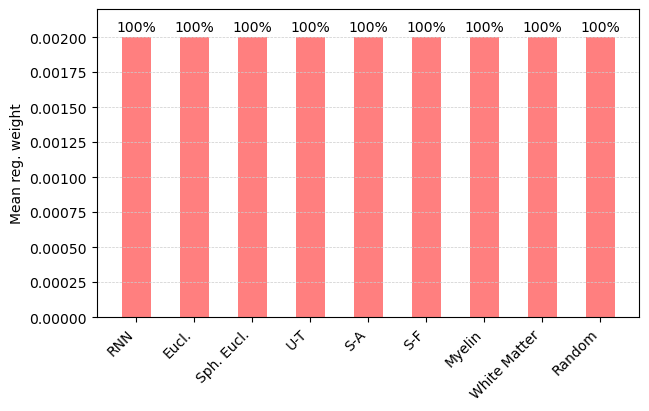

In [124]:
labels = ['RNN']
values = [0.002]
for idx in np.arange(n_maps):
    x = maps[idx]['map_norm'] 
    mask = np.tril(np.ones(x.shape), k=-1).astype(bool)
    s = np.mean(x[mask])
    r = round(values[0]*s,5)
    labels.append(maps[idx]['name'])
    values.append(r)

print(labels)
print(values)
plt.figure(figsize=(7,4))
plt.bar(labels,values,width=0.5,color='red',alpha=0.5)
for idx in np.arange(len(values)):
    plt.text(idx, values[idx]+values[0]*0.02, str(int(100*values[idx]/values[0])) + '%', 
             verticalalignment='baseline', horizontalalignment='center')
plt.ylabel('Mean reg. weight')
plt.grid(axis='y',color=[0.8]*3,linestyle='--',linewidth=0.5)
plt.ylim(top=np.max(values)*1.1)
plt.xticks(rotation=45, ha='right')
plt.show()

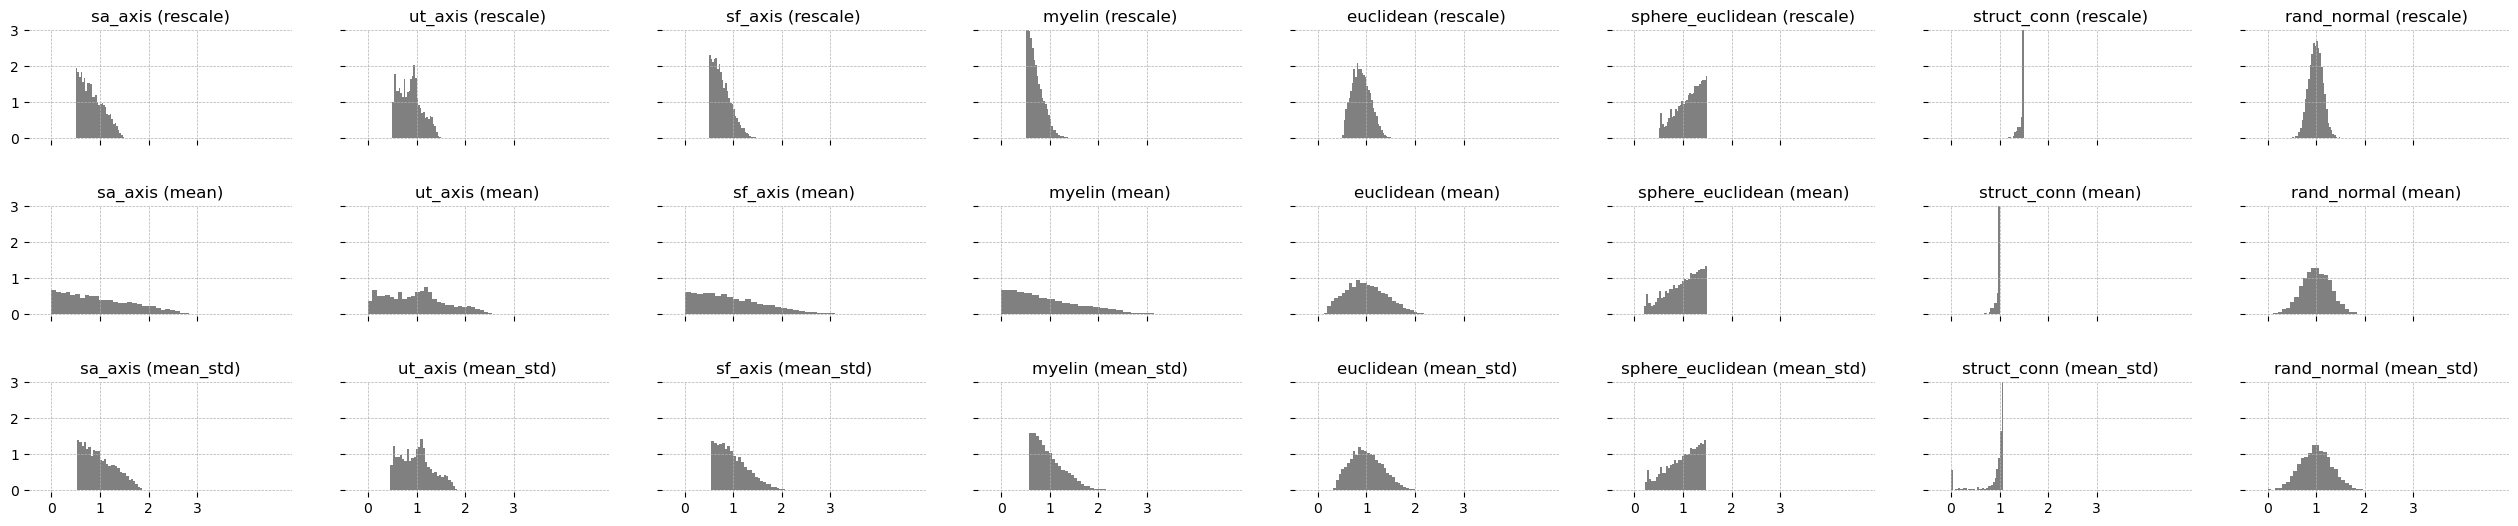

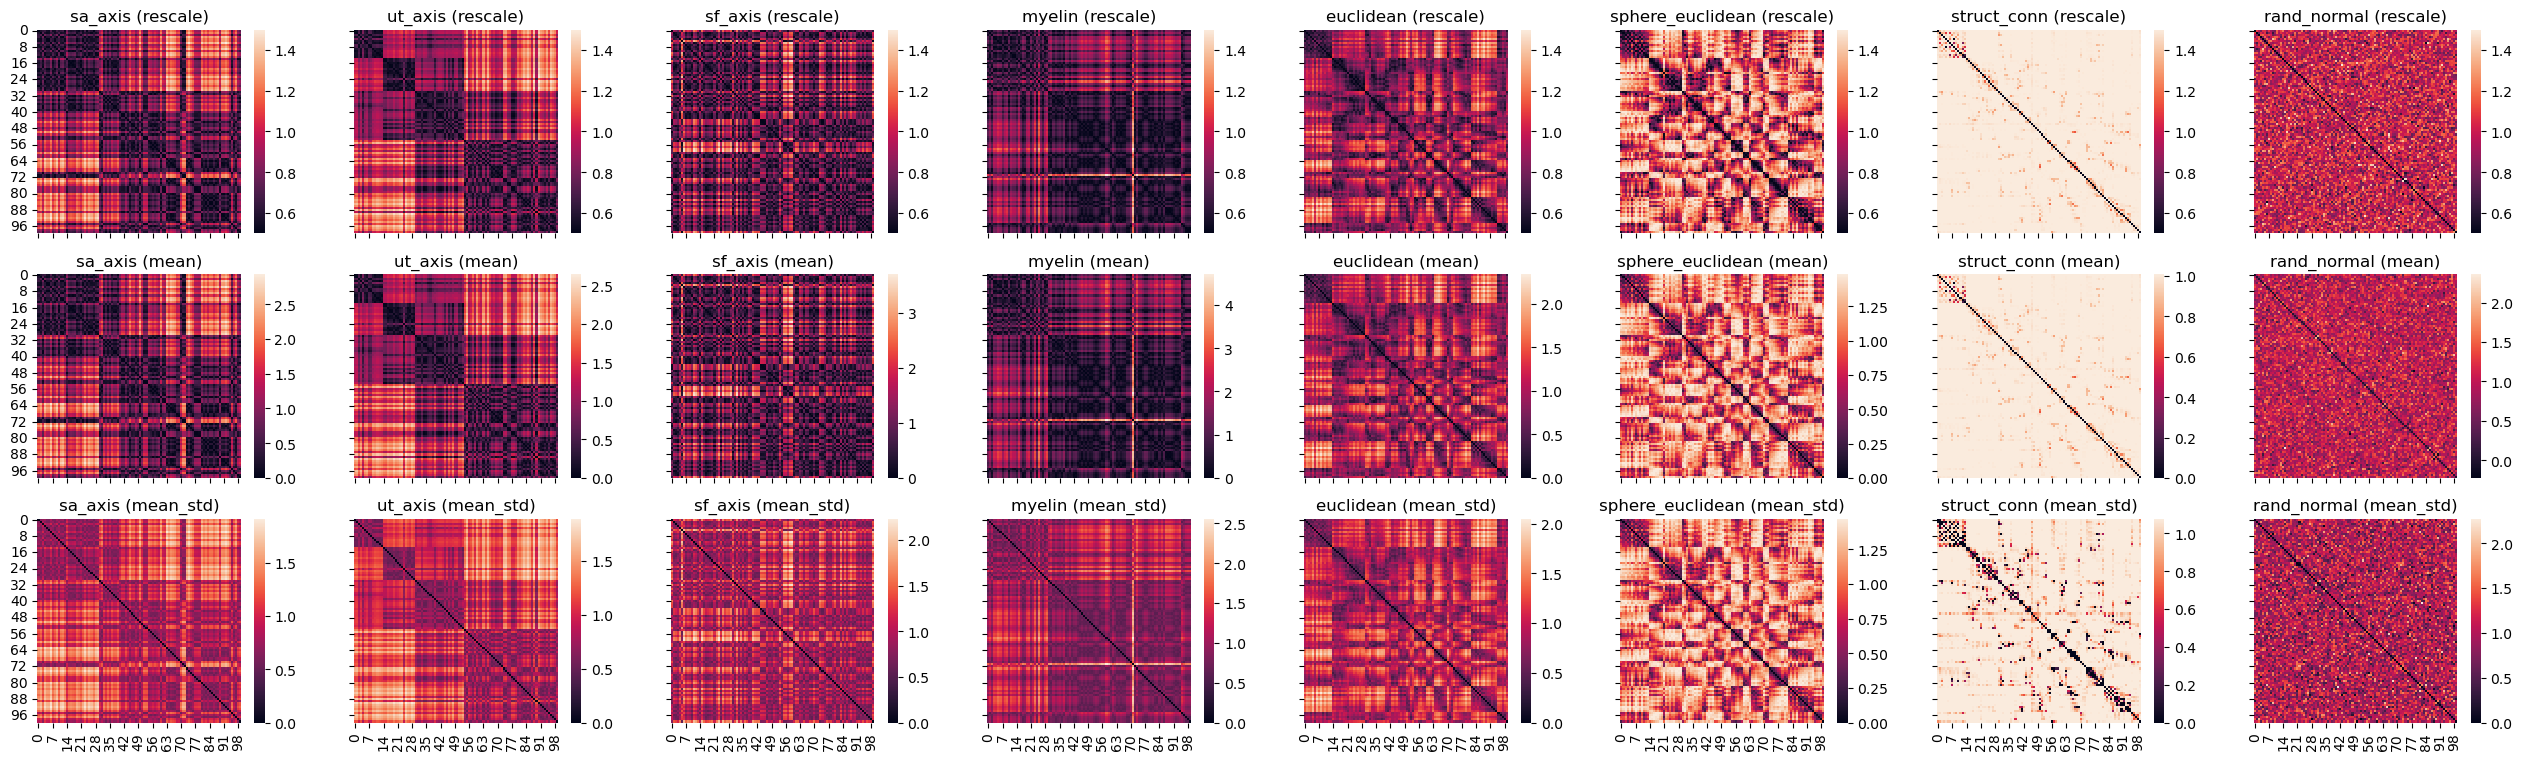

In [135]:
from src import utils 
from scipy.spatial import distance
import matplotlib.pyplot as plt
import seaborn as sns

kernels = [
    'sa_axis',
    'ut_axis',
    'sf_axis',
    'myelin',
    'euclidean',
    'sphere_euclidean',
    'struct_conn',
    'rand_normal'
]
n_kernels = len(kernels)

methods = [
    'rescale',
    'mean',
    'mean_std',
    # 'meansq',
    # 'uniform'
]
n_methods = len(methods)

fig_hist, ax_hist = plt.subplots(nrows=n_methods, ncols=n_kernels, 
                                 figsize=(n_kernels*4, n_methods*2), 
                                 squeeze=False, sharex=True, sharey=True, 
                                 gridspec_kw={'hspace':0.6, 'wspace':0.2})
fig_hm, ax_hm     = plt.subplots(nrows=n_methods, ncols=n_kernels, 
                                 figsize=(n_kernels*4, n_methods*3), 
                                 squeeze=False, sharex=True, sharey=True)

for m in range(n_methods):
    for k in range(n_kernels):
        
        if kernels[k] == 'struct_conn':
            kernel, _ = utils.load_embedding(kernel_type=kernels[k],
                                            datadir='/Users/ahmad/software/snaplab_github/neuro_rnn/data',
                                            hidden_size=100,
                                            kernel_normalization='rescale')
            kernel = np.log1p(kernel-0.5)
            np.fill_diagonal(kernel, 0)
            kernel = utils.normalize_x(kernel, methods[m])
        else:
            kernel, _ = utils.load_embedding(kernel_type=kernels[k],
                                            datadir='/Users/ahmad/software/snaplab_github/neuro_rnn/data',
                                            hidden_size=100,
                                            kernel_normalization=methods[m])
        
        ax_hist[m,k].hist(distance.squareform(kernel), 
                          color=[0.5]*3, 
                          density=True,
                          histtype='bar',
                          bins=30)
        ax_hist[m,k].grid(linestyle='--',linewidth=0.5)
        ax_hist[m,k].set_ylim(-0.05,3)
        ax_hist[m,k].set_yticks(range(4))
        ax_hist[m,k].set_xticks(range(4))
        ax_hist[m,k].set_title(f"{kernels[k]} ({methods[m]})")
        
        sns.heatmap(kernel, 
                    ax=ax_hm[m,k], 
                    cbar=1, 
                    vmin=None if methods[m] in ['mean','meansq', 'mean_std'] else 0.5, 
                    vmax=None if methods[m] in ['mean','meansq', 'mean_std'] else 1.5)
        ax_hm[m,k].set_title(f"{kernels[k]} ({methods[m]})")
        ax_hm[m,k].set_aspect('equal')
        
sns.despine(fig=fig_hist, top=True, right=True, left=True, bottom=True)